Import relevant libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from bokeh.palettes import Viridis8

**Problem 1c**

In [2]:
# Set calibration parameters
alpha = 0.33
beta = 0.99
sigma = 0.01

# Simulate 100,000 shocks of log consumption growth
n_sim = 100000
rng = np.random.default_rng(2)
eps = rng.normal(size=n_sim+1)

# Years
years = np.arange(1, n_sim+1)

# Productivity process
A = np.exp(sigma * eps)

# Capital stock series 
K0 = (alpha * beta) ** (1 / (1 - alpha))  # Start simulation at the steady-state capital stock
K = np.zeros(n_sim + 1)
K[0] = K0
for year in years:
    K[year] = (alpha * beta) * (K[year - 1] ** alpha) * (A[year - 1] ** (1 - alpha))    

# Output series
Y = (K[:-1] ** alpha) * (A[:-1] ** (1 - alpha))

# Consumption series 
C = (1 - alpha * beta) * Y

# Risk-free rate series
R_f = alpha ** alpha * beta ** (alpha - 1) * K[:-1] ** (alpha * (alpha - 1)) * A[:-1] ** (-(1 - alpha)**2) * np.exp(0.5 * (1 - alpha)**2 * sigma**2)

# Equity return series
R_d = alpha ** alpha * beta ** (alpha - 1) * K[:-1] ** (alpha * (alpha - 1)) * A[:-1] ** (-(1 - alpha)**2) * A[1:] ** (1 - alpha) 

# Store all the simulation results in a pandas data frame
sim_df = pd.DataFrame(data={
    'year': years,
    'C': C,
    'Y': Y,
    'I': K[1:],
    'R_f': R_f,
    'R_d': R_d
})
display(sim_df.head())
display(sim_df.tail())


,year,C,Y,I,R_f,R_d
0,1,0.388561,0.577099,0.188538,1.009267,1.005716
1,2,0.386874,0.574594,0.187720,1.012213,1.009393
2,3,0.386603,0.574191,0.187588,1.012689,0.996236
3,4,0.381296,0.566309,0.185013,1.022110,1.034486
4,5,0.390501,0.579981,0.189480,1.005904,1.013622


,year,C,Y,I,R_f,R_d
99995,99996,0.389786,0.578919,0.189133,1.007140,1.010174
99996,99997,0.389814,0.578961,0.189146,1.007091,1.000684
99997,99998,0.386180,0.573563,0.187383,1.013432,1.015885
99998,99999,0.388391,0.576847,0.188456,1.009562,1.018621
99999,100000,0.391667,0.581713,0.190046,1.003896,1.012836


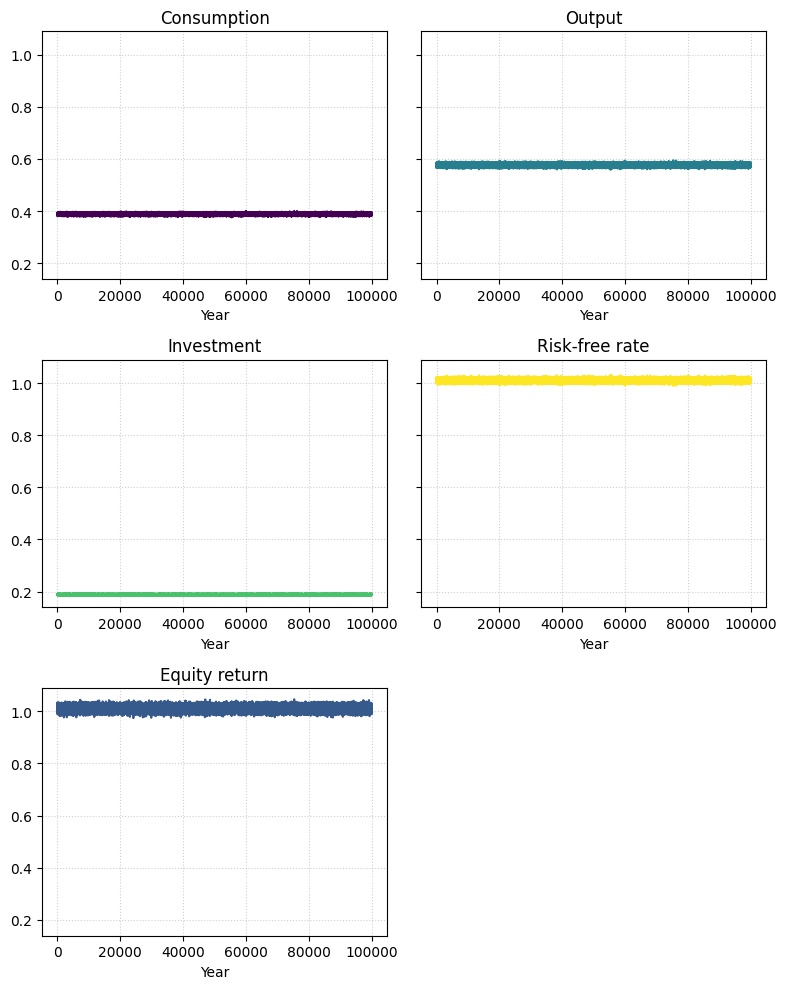

In [3]:
# Plot simulation results

# Common y-limits across all subplots
ymin = min(sim_df['C'].min(), sim_df['Y'].min(), sim_df['I'].min(), sim_df['R_f'].min(), sim_df['R_d'].min())
ymax = max(sim_df['C'].max(), sim_df['Y'].max(), sim_df['I'].max(), sim_df['R_f'].max(), sim_df['R_d'].max())
pad = 0.05 * (ymax - ymin)
ylims = (ymin - pad, ymax + pad)

# --- Figure with 5 subplots sharing y-axis ---
fig, axs = plt.subplots(3, 2, figsize=(8, 10), sharex=True, sharey=True)

axs = axs.ravel()
axs[0].plot(sim_df['year'], sim_df['C'], color=Viridis8[0])
axs[0].set_title("Consumption")

axs[1].plot(sim_df['year'], sim_df['Y'], color=Viridis8[3])
axs[1].set_title("Output")

axs[2].plot(sim_df['year'], sim_df['I'], color=Viridis8[5])
axs[2].set_title("Investment")

axs[3].plot(sim_df['year'], sim_df['R_f'], color=Viridis8[7])
axs[3].set_title("Risk-free rate")

axs[4].plot(sim_df['year'], sim_df['R_d'], color=Viridis8[2])
axs[4].set_title("Equity return")

fig.delaxes(axs[5])

for ax in axs:
    ax.set_ylim(*ylims)
    ax.set_xlabel("Year")
    ax.grid(True, linestyle=':', alpha=0.6)
    #plt.setp(ax.get_xticklabels(), visible=False)

for ax in axs:
    ax.tick_params(axis='x', which='both', labelbottom=True)


fig.tight_layout()
plt.show()


In [4]:
# Compute the mean, standard deviation, and first autocorrelation of each series
col_labels = {
    'C': 'Consumption',
    'Y': 'Output',
    'I': 'Investment', 
    'R_f': 'Risk-free rate',
    'R_d': 'Equity return',
}

for col in ['C', 'Y', 'I', 'R_f', 'R_d']:
    print(col_labels[col])
    print(f'Mean: {np.mean(sim_df[col]):.4f}')
    print(f'Standard deviation: {np.std(sim_df[col], ddof=1):.4f}')
    print(f'First autocorrelation: {sim_df[col].autocorr(lag=1):.4f}')
    print('-'*50)

Consumption
Mean: 0.3881
Standard deviation: 0.0028
First autocorrelation: 0.3313
--------------------------------------------------
Output
Mean: 0.5764
Standard deviation: 0.0041
First autocorrelation: 0.3313
--------------------------------------------------
Investment
Mean: 0.1883
Standard deviation: 0.0013
First autocorrelation: 0.3313
--------------------------------------------------
Risk-free rate
Mean: 1.0101
Standard deviation: 0.0048
First autocorrelation: 0.3313
--------------------------------------------------
Equity return
Mean: 1.0101
Standard deviation: 0.0083
First autocorrelation: -0.3344
--------------------------------------------------


**Problem 1d**

In [5]:
# Markov chain approximation for log A
def tauchen(N, rho, sigma_eps, m=3):
    """
    AR(1): x_t = rho x_{t-1} + sigma_eps * eps_t, eps~N(0,1)
    Returns grid x (size N) and transition matrix P (N x N).
    """
    std_x = sigma_eps / np.sqrt(1 - rho**2)
    x_max = m * std_x
    x_min = -x_max
    grid = np.linspace(x_min, x_max, N)
    step = (x_max - x_min) / (N - 1)
    P = np.empty((N, N))

    for j in range(N):
        for k in range(N):
            if k == 0:
                z = (grid[0] - rho * grid[j] + step / 2) / sigma_eps
                P[j, k] = norm.cdf(z)
            elif k == N - 1:
                z = (grid[-1] - rho * grid[j] - step / 2) / sigma_eps
                P[j, k] = 1 - norm.cdf(z)
            else:
                z_up = (grid[k] - rho * grid[j] + step / 2) / sigma_eps
                z_down = (grid[k] - rho * grid[j] - step / 2) / sigma_eps
                P[j, k] = norm.cdf(z_up) - norm.cdf(z_down)

    return grid, P

Nz = 3
rho = 0   
logA_grid, Pz = tauchen(Nz, rho, sigma)
A_grid = np.exp(logA_grid)

# Capital grid
Nk = 200
k_min = 0.1 * K0
k_max = 1.9 * K0
K_grid = np.linspace(k_min, k_max, Nk)

# Value function iteration
V = np.zeros((Nk, Nz))
policy_K_idx = np.zeros((Nk, Nz), dtype=int)

tol = 1e-6
max_iter = 5000

for it in range(max_iter):
    V_new = np.empty_like(V)
    EV = V @ Pz.T

    for iz in range(Nz):
        A = A_grid[iz]
        EV_next = EV[:, iz]
        for ik in range(Nk):
            K = K_grid[ik]
            Kprime = K_grid
            C = A * (K ** alpha) - Kprime
            # Discard negative consumption
            feasible = C > 0
            value_vec = -1e10 * np.ones_like(C)
            value_vec[feasible] = np.log(C[feasible]) + beta * EV_next[feasible]
            best_idx = np.argmax(value_vec)
            V_new[ik, iz] = value_vec[best_idx]
            policy_K_idx[ik, iz] = best_idx

    diff = np.max(np.abs(V_new - V))
    V = V_new
    if diff < tol:
        print(f"VFI converged in {it+1} iterations, diff={diff:.2e}")
        break
else:
    print("Warning: did not converge")

# Recover the optimal policy for capital
K_policy = K_grid[policy_K_idx]

# Compute optimal consumption policy
K_mat = K_grid.reshape(-1, 1)   
A_mat = A_grid.reshape(1, -1)   
C_policy = (A_mat ** (1-alpha))  * ((K_mat ** alpha)) - K_policy

# Analytical policies            
K_policy_ana = alpha * beta * (K_mat ** alpha) * (A_mat ** (1 - alpha))
C_policy_ana = (1 - alpha * beta) * (K_mat ** alpha) * (A_mat ** (1 - alpha))


VFI converged in 1371 iterations, diff=9.96e-07


Plot numerical policies against numerical policies

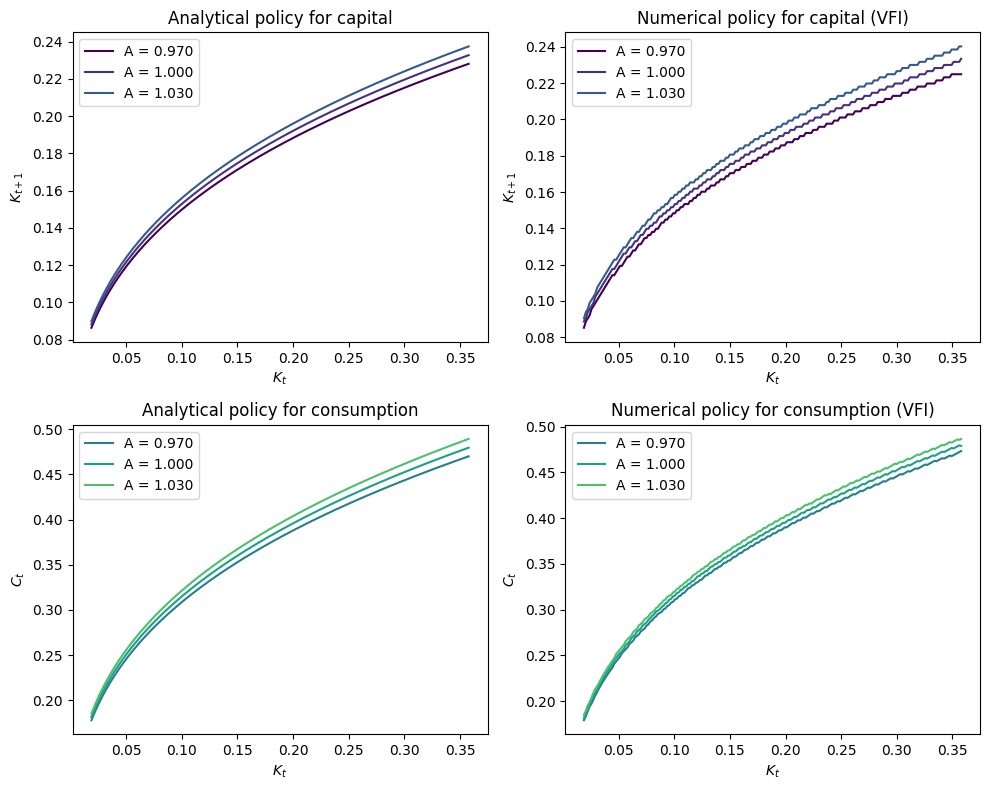

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs = axs.ravel()

# Capital policy, analytical
for iz, A in enumerate(A_grid):
    axs[0].plot(K_grid, K_policy_ana[:, iz], label=f"A = {A:.3f}", color=Viridis8[iz])
axs[0].set_xlabel(r"$K_t$")
axs[0].set_ylabel(r"$K_{t+1}$")
axs[0].set_title("Analytical policy for capital")

# Capital policy, numerical
for iz, A in enumerate(A_grid):
    axs[1].plot(K_grid, K_policy[:, iz], label=f"A = {A:.3f}", color=Viridis8[iz])
axs[1].set_xlabel(r"$K_t$")
axs[1].set_ylabel(r"$K_{t+1}$")
axs[1].set_title("Numerical policy for capital (VFI)")

# Consumption policy, analytical
for iz, A in enumerate(A_grid):
    axs[2].plot(K_grid, C_policy_ana[:, iz], label=f"A = {A:.3f}", color=Viridis8[iz+3])
axs[2].set_xlabel(r"$K_t$")
axs[2].set_ylabel(r"$C_t$")
axs[2].set_title("Analytical policy for consumption")

# Consumption policy, numerical
for iz, A in enumerate(A_grid):
    axs[3].plot(K_grid, C_policy[:, iz], label=f"A = {A:.3f}", color=Viridis8[iz+3])
axs[3].set_xlabel(r"$K_t$")
axs[3].set_ylabel(r"$C_t$")
axs[3].set_title("Numerical policy for consumption (VFI)")

for i in range(4): axs[i].legend(loc='best')
fig.tight_layout()
